In [1]:
# %matplotlib inline

import matplotlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24
MSU_GREEN = "#18453B" 

matplotlib.rc('font', size=SMALL_SIZE)          # controls default text sizes
matplotlib.rc('axes', titlesize=MEDIUM_SIZE)    # fontsize of the axes title
matplotlib.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
matplotlib.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
matplotlib.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
matplotlib.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# 1-D Hyrdodynamics Solver

This notebook will lay out a hydrodynamics solver that solves Sod's shock tube.

The results should mimic figures 8.9 and 8.10

Euler's Equation in conservative form:

$$
\mathcal{U}_t + [\textbf{F}(\mathcal{U})]_x = 0
$$

with

$$
\mathcal{U} =
\begin{bmatrix}
\rho \\ \rho u \\ \rho E
\end{bmatrix}

\quad \quad \quad

\textbf{F}(\mathcal{U}) =
\begin{bmatrix}
\rho u \\ \rho uu + p \\ \rho u E + u p
\end{bmatrix}
$$


$E$ is the total energy/mass $$ E = e + \frac{1}{2} u^2,$$ and the equations are closed with a gamma law equation of state, $$p = \rho e(\gamma - 1),$$ where $\gamma$ is the ratio of specific heats for the gas/fluid (for an ideal, monatomic gas, $\gamma = 5/3$). 

For the Sod problem, as described by (8.9.1), we will use $\gamma = 1.4$ and IC of

$$
\begin{align*}
\rho_l = 1 \quad \quad & \quad \quad \rho_r = 1/8 \\
u_l = 0 \quad \quad & \quad \quad u_r = 0 \\
p_l = 1 \quad \quad & \quad \quad p_r = 1/10
\end{align*}
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#number of ghost cells for Bcs
nghost = 2

# degrees of freedom for solution vector
DOFs_sod = 3

In [4]:
# Initial conditions
def sods_shock_tube_IC(x, gamma):
    if 0 <= x < 0.5:
        rho_init = 1
        u_init = 0
        p_init = 1
    elif 0.5 <= x <= 1:
        rho_init = 1/8
        u_init = 0
        p_init = 1/10
    else:
        print('error in sod IC')
    
    rho = rho_init
    rho_u = rho_init * u_init
    rho_E = p_init/(gamma - 1) + 0.5*rho_u*u_init*u_init
    U_element = np.array([rho, rho_u, rho_E])
    return U_element


In [5]:
# plotting Sod IC and figuring out vector valued indexing

# DOFs_sod = 3
# nx_IC = 10
# dx_IC = 1/nx_IC
# gamma = 1.4

# X_IC = np.linspace(0,1, nx_IC)

# #need vector valued solution vector U = (rho, rho u, rho E)
# U_IC = np.array([sods_shock_tube_IC(x, gamma) for x in X_IC]) # shape (nx, DOF)
# U_IC = U_IC.T # shape (DOF, nx)
# U_ghost_ic = np.zeros((DOFs_sod, nx_IC + 2*nghost)) #shape (DOF, nx+ghosts)
# U_ghost_ic[:, nghost:nghost+nx_IC] = U_IC # ghosted vector able to have Bcs

# rho_0 = U_IC[0]
# rho_u_0 = U_IC[1]
# rho_E_0 = U_IC[2]

# u_0 = rho_u_0 / rho_0
# E_0 = rho_E_0 / rho_0
# e_0 = E_0 - 0.5*u_0*u_0
# p_0 = rho_0*e_0*(gamma - 1)


# plt.figure(figsize=(12, 5))
# plt.subplot(1, 4, 1)
# plt.plot(X_IC, rho_0, label=f'rho_0')
# plt.legend()
# plt.subplot(1, 4, 2)
# plt.plot(X_IC, u_0, label=f'u_0')
# plt.legend()
# plt.subplot(1,4,3)
# plt.plot(X_IC, p_0, label=f'p_0')
# plt.legend()
# plt.subplot(1,4,4)
# plt.plot(X_IC, e_0, label=f'e_0')
# plt.legend()

# plt.show()



In [6]:
# Outflow BC: 

def fill_ghost_outflow_bc(U,nx):
    # left boundary
    for i in range(DOFs_sod):
        U[i, 0:nghost] = U[i, nghost]
        
        #right boundary
        U[i, nghost+nx:] = U[i, nghost+nx-1]
    
    return U


# print(U_ghost_ic)

# U_bc = fill_ghost_outflow_bc(U_ghost_ic, nx_IC)

# print(U_bc)

In [7]:
# conservative form to primitive form helper function

# takes in U(rho, rho_u, rho_E)
# returns  U(rho, u, p)
def cons_to_prim(U, gamma):
    # grab conservative variables
    rho_cons      = U[0]
    rho_u_cons    = U[1]
    rho_E_cons    = U[2]
    
    # new solution vector to return
    U_prim = np.zeros_like(U)
    
    #pull out primitive variables
    rho_prim = rho_cons
    u_prim   = rho_u_cons/rho_cons
    E_prim   = rho_E_cons/rho_cons
    e_prim   = E_prim - 0.5*u_prim*u_prim
    p_prim   = rho_prim * e_prim * (gamma - 1)

    #assign primitive variables inside new U
    U_prim[0] = rho_prim
    U_prim[1] = u_prim
    U_prim[2] = p_prim
    
    return U_prim



# Riemann Solver

This is the Riemann solver described by Zingale. I have seen him refer to it as the CGF solver,
but I am not sure what that stands for. It is much more complex than HLL or HLLC. I wrote this before I found Toro's book, so a lot of these equation references to Toro's chapter 4 are pulled from Zingale's code.

- compute sound speeds
- find p* and u*
- find rho*
- determine which state is at the interface

In [8]:
from scipy.optimize import brentq

def rho_star_s(rho_s, p_s, p_star, gamma):    
    p_ratio = p_star/p_s

    gam_fac = (gamma - 1.0)/(gamma + 1.0)
    
    if p_star > p_s:
        # get rho_star for shock (eq. 7.86 in Zingale I believe, but this is from his code)
        rho_star_s = rho_s * (p_ratio + gam_fac)/(gam_fac * p_ratio + 1.0)
    else: # rarefaction 4.53/4.60 from toro (zingales code says)
        rho_star_s = rho_s*p_ratio**(1/gamma)
    
    return rho_star_s

def u_star_s(p, u_s, p_s, c_s, sign, gamma):
    sign_val = 1.0 if sign == '+' else -1.0
    
    if p <= p_s:
        exp = (gamma - 1) / (2 * gamma)
        return u_s + sign_val * 2*c_s/(gamma-1) * (1 - (p/p_s)**exp)
    else:  # p > p_s
        return u_s + sign_val * c_s * (2/(gamma*(gamma-1)))**0.5 * (1 - p/p_s) / ((p/p_s*(gamma+1)/(gamma-1) + 1)**0.5)

def find_p_star(u_L, p_L, c_L, u_R, p_R, c_R, gamma):
    # find p* by solving eqn 7.92 iteratively 
    # u*,l(p*) - u*,r(p*) = 0   (7.92)
    
    p_min=1e-10
    p_max=1000.0
    f = lambda p: u_star_s(p, u_L, p_L, c_L, '+', gamma) - u_star_s(p, u_R, p_R, c_R, '-', gamma)
    p_star = brentq(f, p_min, p_max)
    
    return p_star

def Riemann(U_L, U_R, gamma):
    # get primitive form for easier computation
    U_L_prim = cons_to_prim(U_L, gamma)
    U_R_prim = cons_to_prim(U_R, gamma)
    
    rho_L = U_L_prim[0]
    u_L   = U_L_prim[1]
    p_L   = U_L_prim[2]
    
    rho_R = U_R_prim[0]
    u_R   = U_R_prim[1]
    p_R   = U_R_prim[2]
    
    #compute speeds of sound c
    c_L = np.sqrt(gamma*p_L/rho_L)
    c_R = np.sqrt(gamma*p_R/rho_R)
    
    # find p*
    p_star = find_p_star(u_L, p_L, c_L, u_R, p_R, c_R, gamma)
    
    # find u*
    u_star = u_star_s(p_star, u_L, p_L, c_L, '+', gamma)
    
    # find rho_L* and rho_R*
    rho_L_star = rho_star_s(rho_L, p_L, p_star, gamma)
    rho_R_star = rho_star_s(rho_R, p_R, p_star, gamma)
    
    # now finally find which interface we are in
    U = np.zeros_like(U_L)
    p_ratio_L = p_star/p_L
    p_ratio_R = p_star/p_R
    cstar_L   = c_L*p_ratio_L**((gamma-1.0)/(2*gamma))
    cstar_R   = c_R*p_ratio_R**((gamma-1.0)/(2*gamma))
    gam_fac = (gamma-1.0)/(gamma+1.0)
    # Check 1 - contact wave (speed u*)
    if u_star >= 0:     # moved right past the interface, we are in L or L*
        if p_star > p_L: #shock condition
            # shock speed
            S_L = u_L + -1.0*c_L*np.sqrt(0.5*(gamma + 1.0)/(gamma) * (p_ratio_L) + 0.5*(gamma-1.0)/gamma)
            if S_L > 0: #we are in L
                U = U_L.copy()
            else: # we are in L*
                U[0] = rho_L_star
                U[1] = rho_L_star * u_star
                U[2] = p_star/(gamma-1) + rho_L_star * u_star*u_star/2.0
        else : # rarefaction condition
            lambda_head = u_L - c_L
            lambda_tail = u_star - cstar_L
            if lambda_head > 0: # we are in L
                U = U_L.copy()
            elif lambda_tail < 0: # we are in L*
                U[0] = rho_L_star
                U[1] = rho_L_star * u_star
                U[2] = p_star/(gamma-1) + rho_L_star * u_star*u_star/2.0
            else: # we are in fan -- Toro 4.56/4.63 -- according to Zingale code
                rho_fan_L = rho_L * (2/(gamma + 1.0) - -1.0*gam_fac*(u_L - 0.0)/c_L)**(2.0/(gamma-1.0))
                u_fan_L = 2.0/(gamma+1.0) * (-1.0 * -1.0*c_L + 0.5*(gamma-1.0)*u_L + 0.0)
                p_fan_L = p_L * (2.0/(gamma+1.0) - -1.0*gam_fac*(u_L-0.0)/c_L)**(2.0*gamma/(gamma-1.0))
                U[0] = rho_fan_L
                U[1] = rho_fan_L * u_fan_L
                U[2] = p_fan_L/(gamma-1) + rho_fan_L * u_fan_L*u_fan_L/2.0
    elif u_star < 0: # we moved left past the interface, we are in R or R*
        if p_star > p_R: # shock condition
            # shock speed
            S_R = u_R + 1.0*c_R*np.sqrt(0.5*(gamma + 1.0)/(gamma) *(p_ratio_R) + 0.5*(gamma-1.0)/gamma)
            if S_R < 0: #we are in R
                U = U_R.copy()
            else: # we are in R*
                U[0] = rho_R_star
                U[1] = rho_R_star * u_star
                U[2] = p_star/(gamma-1) + rho_R_star * u_star*u_star/2.0
        else : # rarefaction condition
            lambda_head = u_R + c_R
            lambda_tail = u_star + cstar_R
            if lambda_head < 0: # we are in R
                U = U_R.copy()
            elif lambda_tail > 0: # we are in R*
                U[0] = rho_R_star
                U[1] = rho_R_star * u_star
                U[2] = p_star/(gamma-1) + rho_R_star * u_star*u_star/2.0
            else: # we are in fan -- Toro 4.56/4.63
                rho_fan_R = rho_R * (2/(gamma + 1.0) - 1.0*gam_fac*(u_R - 0.0)/c_R)**(2.0/(gamma-1.0))
                u_fan_R = 2.0/(gamma+1.0) * (-1.0 * 1.0*c_R + 0.5*(gamma-1.0)*u_R + 0.0)
                p_fan_R = p_R * (2.0/(gamma+1.0) - 1.0*gam_fac*(u_R-0.0)/c_R)**(2.0*gamma/(gamma-1.0))
                U[0] = rho_fan_R
                U[1] = rho_fan_R * u_fan_R
                U[2] = p_fan_R/(gamma-1) + rho_fan_R * u_fan_R*u_fan_R/2.0
    return U

In [9]:
# setup function that computes the flux eqn. 8.55

def compute_flux(q, gamma):
    q_prim = cons_to_prim(q, gamma)
    
    rho = q_prim[0]
    u   = q_prim[1]
    p   = q_prim[2]
    
    F = np.zeros(3)
    F[0] = rho * u
    F[1] = rho * u*u + p
    F[2] = u*p / (gamma -1) + 0.5*rho *(u*u*u) + u*p
    
    return F

In [10]:
def piecewise_constant(U):
    return U, U

In [11]:
def minmod(a, b): #vectorized like Carolyn's so input can be vector valued
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))

def compute_interface_states_MC(U, dx, dt):
    n = len(U[0])
    U_L = np.zeros_like(U)
    U_R = np.zeros_like(U)

    for i in range(nghost - 1, n - nghost + 1):
        dc = 0.5 * (U[:,i+1] - U[:,i-1])   # centered difference
        dl = U[:,i+1] - U[:,i]              # forward difference
        dr = U[:,i] - U[:,i-1]              # backward difference

        # MC limiter (van Leer 1977, as in LeVeque 2002) -- zingales burgers code
        d1 = 2.0 * minmod(dl, dr)       
        ldeltau = minmod(dc, d1)         

        U_L[:,i] = U[:,i] + 0.5 * (1.0 - U[:,i]*dt/dx) * ldeltau
        U_R[:,i] = U[:,i] - 0.5 * (1.0 + U[:,i]*dt/dx) * ldeltau

    return U_L, U_R

def piecewise_linear(U, dx, dt):
    U_L, U_R = compute_interface_states_MC(U, dx, dt)
    return U_L, U_R

In [12]:

def evolve(U_ghosted, nx, C, t_final, gamma, Godunov_type):
    dx = 1.0 / nx

    U = U_ghosted.copy()

    all_solns = [] # movie  stuff
    all_t     = [] # for movie purposes
    t = 0.0
    
    all_solns.append(U[:, nghost:nghost+nx].copy())
    all_t.append(t)
    while t < t_final:
        
        # fill ghost cells with outflow BC
        fill_ghost_outflow_bc(U, nx)
        
        # get the timestep based on the CFL condition, but also make sure we don't step past t_final
        U_prim = cons_to_prim(U[:, nghost:nghost+nx], gamma) #U(rho, u, p)
        c = np.sqrt(gamma*U_prim[2]/U_prim[0]) # sound speed in medium 
        dt = C * dx / np.max(np.abs(U_prim[1]) + c)  # CFL condition based on max velocity in the domain
        dt = min(dt, t_final - t) # adjust final time step to hit t_final exactly
        
        #get the interface states using the specified reconstruction method
        if Godunov_type == 0: # piecewise constant has U_L = U[:, i] and U_R = U[:, i+1], but we have a function anyways
            U_L, U_R = piecewise_constant(U)
        if Godunov_type == 1:
            U_L, U_R = piecewise_linear(U, dx, dt)
        
        # do the update
        F = np.zeros_like(U)
        for i in range(nghost-1, nghost+nx):
            q = Riemann(U_L[:, i], U_R[:, i+1], gamma) # returns conservative state at interface
            
            #calculate Riemann flux
            F[:, i] = compute_flux(q, gamma)
        
        for i in range(nghost, nghost+nx):
            U[:, i] = U[:, i] - (dt/dx) * (F[:, i] - F[:, i-1])
        t += dt
        
        all_solns.append(U[:, nghost:nghost+nx].copy())
        all_t.append(t)

    return U[:, nghost:nghost+nx], all_solns, all_t

In [13]:
def plot_solution(grid, U_Sol, t, gamma, case='Sod', Godonuv_type='Piecewise Constant'):
    '''
    Definition: plots density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid  : array of x coordinates
                q_sys : conserved variables (ρ, ρu, ρE)^T
                t     : current time
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    matplotlib figure showing Euler quantities

    '''

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)
    
    rho_sol = U_Sol[0]
    rho_u_sol = U_Sol[1]
    rho_E_sol = U_Sol[2]

    u_sol = rho_u_sol / rho_sol
    E_sol = rho_E_sol / rho_sol
    e_sol = E_sol - 0.5*u_sol*u_sol
    p_sol = rho_sol*e_sol*(gamma - 1)
    
    fig, plots = plt.subplots(2, 2, figsize=(18, 10), dpi=300)

    fig.suptitle(f'{case} Shock Tube at t = {t:.2f}')

    plt.rcParams['axes.grid'] = True
    plt.rcParams['grid.color'] = 'lavender'
    plt.rcParams['grid.linestyle'] = '-'
    plt.rcParams['grid.linewidth'] = 0.8

    CE = 'k' 

    # Top Left Plot
    plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2, label='Exact')
    plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5, label=f'{Godonuv_type}')
    plots[0][0].set_title('Density')
    plots[0][0].set_xlim([0,1]);# plots[0][0].set_ylim([0.0,1.05]) 
    plots[0][0].legend() 
    
    # Bottom Left Plot
    plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
    plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][0].set_title('Pressure')
    plots[1][0].set_xlim([0,1]);# plots[0][1].set_ylim([0.0,1.05])

    # Top Left Plot
    plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
    plots[0][1].plot(grid, u_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[0][1].set_title(r'$v_x$')
    plots[0][1].set_xlim([0,1]);# plots[1][0].set_ylim([-0.4,0.8])

    # Bottom Left Plot
    plots[1][1].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
    plots[1][1].plot(grid, rho_E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
    plots[1][1].set_title('Total Energy')
    plots[1][1].set_xlim([0,1]);# plots[1][1].set_ylim([-1.7,0.1])

    # plt.savefig(f"{case}.png",dpi=200)

    plt.show()

In [14]:
def movie_maker(grid, all_solns, all_t, gamma, case):
    '''
    Definition: creates a movie of the 1D Euler solution: 
                density, pressure, energy, velocity components, and magnetic fields

    Inputs:     grid      : array of x coordinates
                all_solns : list of conserved variable arrays (ρ, ρu, ρE)^T at each time step
                all_t     : array of all time steps
                gamma : adiabatic index
                case : various 1D test cases 

    Outputs:    movie showing Euler quantities

    '''

    n_steps = len(all_t)

    exact_grid, exact_rho, exact_vex, exact_vey, exact_vez, exact_pre, exact_Bx, exact_By, exact_Bz, exact_E = np.loadtxt(f"exact_solutions/{case}.txt", unpack=True, skiprows=1,)

    # Create a figure and axis for plotting
    fig, plots = plt.subplots(2, 2, figsize=(18, 10), dpi=200)

    def animate(i):
        ''' function to update the plot for each frame  '''

        plots[0][0].clear()
        plots[1][0].clear()
        plots[0][1].clear()
        plots[1][1].clear()

        t = all_t[i]
        U_frame = all_solns[i]  # get the i-th snapshot

        rho_sol   = U_frame[0]
        rho_u_sol = U_frame[1]
        rho_E_sol = U_frame[2]

        u_sol = rho_u_sol / rho_sol
        E_sol = rho_E_sol / rho_sol
        e_sol = E_sol - 0.5*u_sol*u_sol
        p_sol = rho_sol*e_sol*(gamma - 1)
        
        fig.suptitle(f'{case} Shock Tube at t = {t:.3f}')

        plt.rcParams['axes.grid'] = True
        plt.rcParams['grid.color'] = 'lavender'
        plt.rcParams['grid.linestyle'] = '-'
        plt.rcParams['grid.linewidth'] = 0.8

        CE = 'k' 

        # Top Left Plot
        plots[0][0].plot(exact_grid, exact_rho, color=CE, linestyle='-', linewidth=2)
        plots[0][0].plot(grid, rho_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][0].set_title('Density')
        plots[0][0].set_xlim([0,1])

        # Bottom Left Plot
        plots[1][0].plot(exact_grid, exact_pre, color=CE, linestyle='-', linewidth=2)
        plots[1][0].plot(grid, p_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][0].set_title('Pressure')
        plots[1][0].set_xlim([0,1])

        # Top Right Plot
        plots[0][1].plot(exact_grid, exact_vex, color=CE, linestyle='-', linewidth=2)
        plots[0][1].plot(grid, u_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[0][1].set_title(r'$v_x$')
        plots[0][1].set_xlim([0,1])

        # Bottom Right Plot
        plots[1][1].plot(exact_grid, exact_E, color=CE, linestyle='-', linewidth=2)
        plots[1][1].plot(grid, rho_E_sol, color=MSU_GREEN, linestyle='dotted', linewidth=2.5)
        plots[1][1].set_title('Total Energy')
        plots[1][1].set_xlim([0,1])

    # Create the animation using matplotlib's FuncAnimation
    ani = animation.FuncAnimation(fig, animate, frames=n_steps, interval=1, blit=False)
    # Save the animation as a video file
    ani.save(f"{case}.gif", writer='pillow', fps=30, dpi=100)

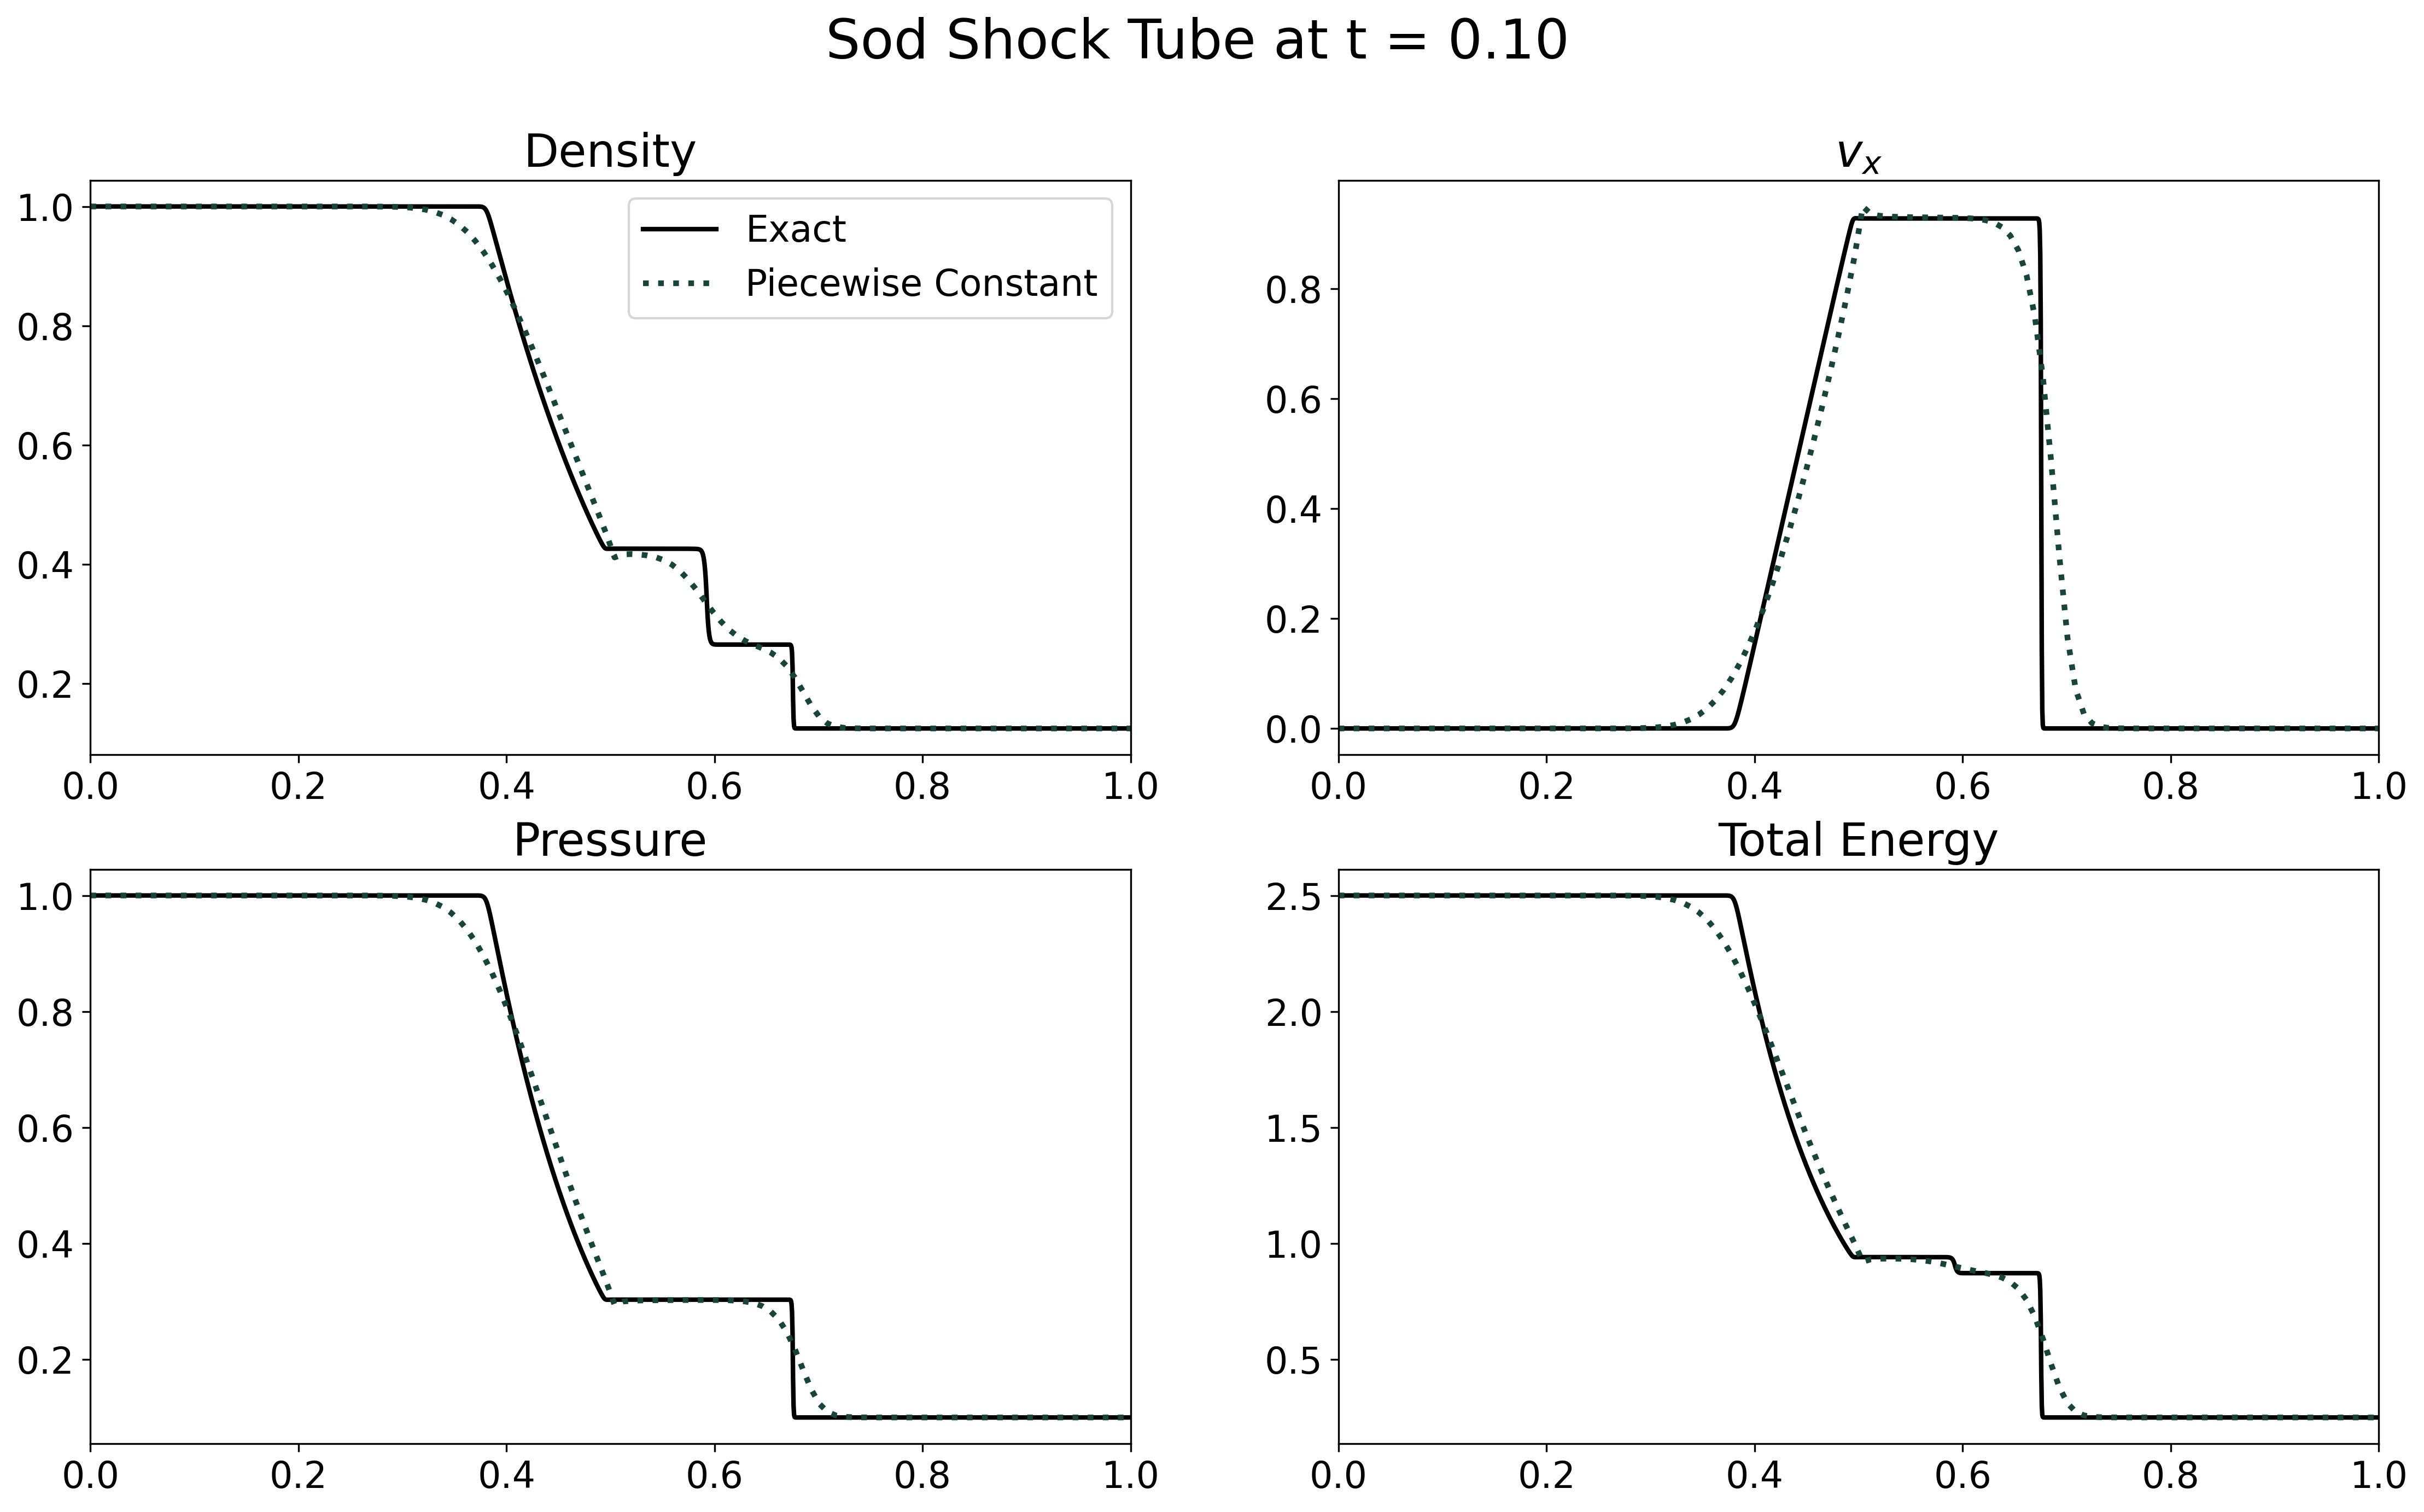

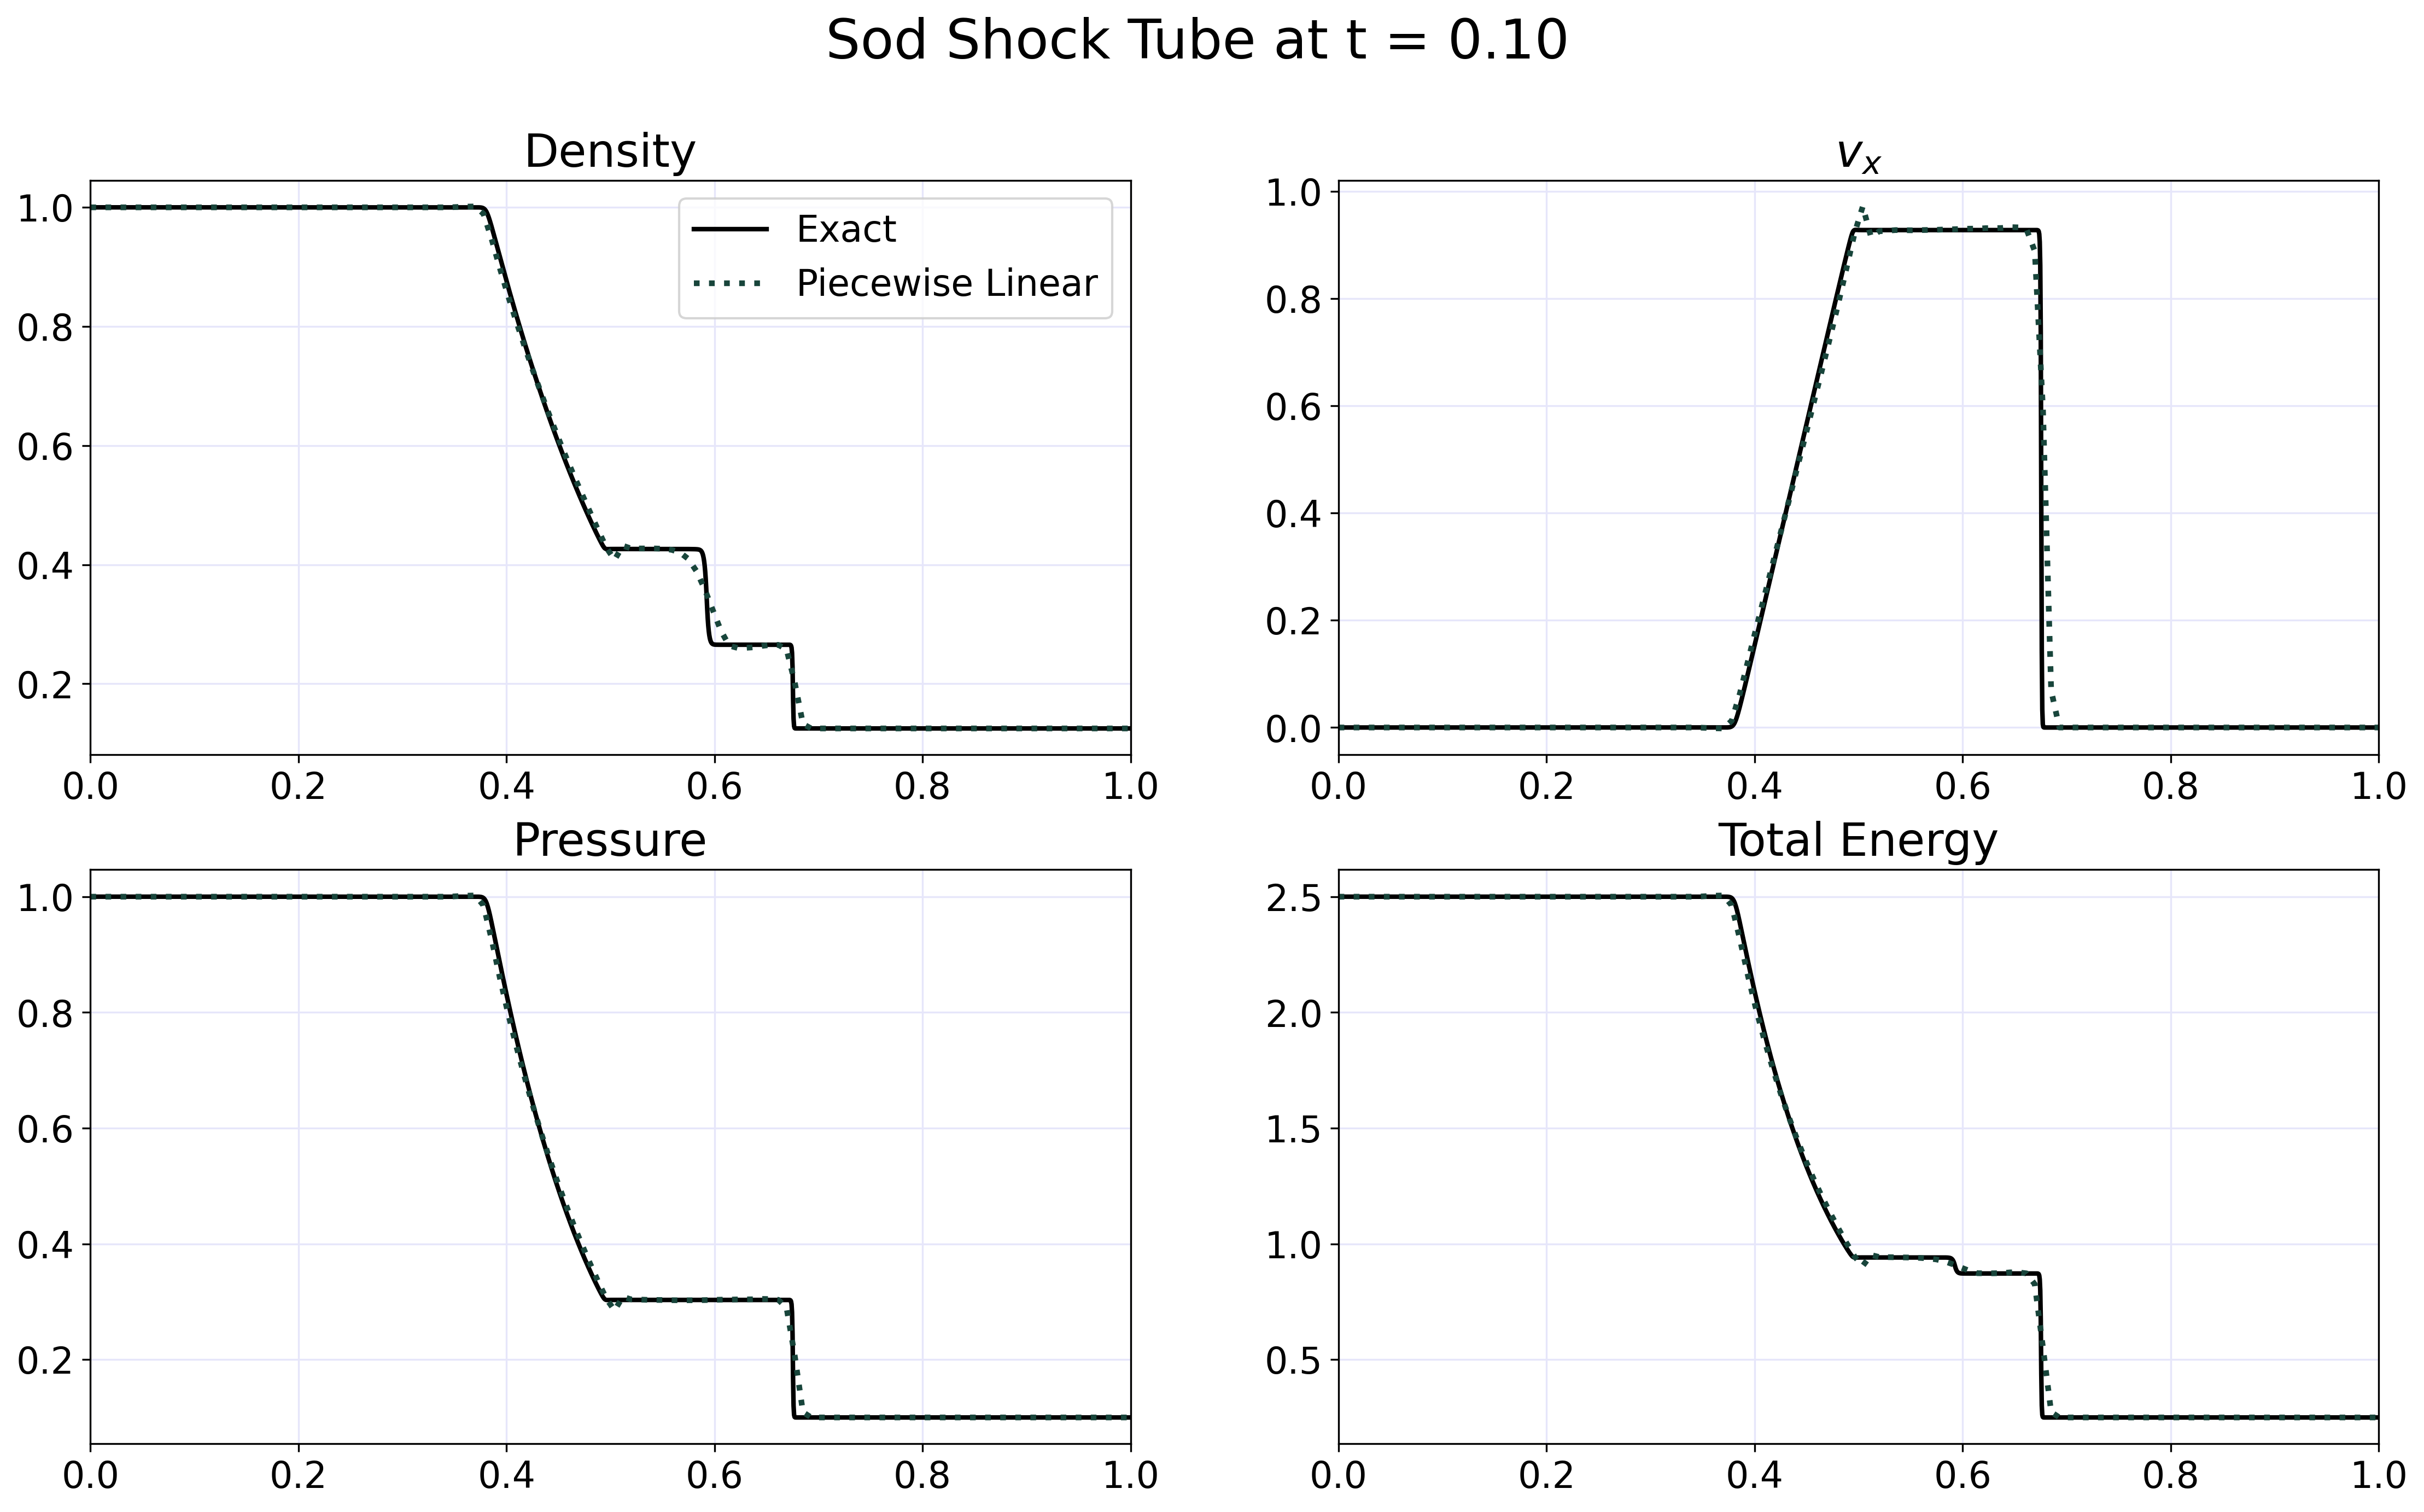

In [15]:
# Sod problem setting up variables and visualizing

DOFs_sod = 3
nx = 128
dx = 1/nx
C = 0.1
gamma = 1.4
tf = 0.1

X = np.linspace(0,1, nx)

#need vector valued solution vector U = (rho, rho u, rho E)
U_IC_Sod = np.array([sods_shock_tube_IC(x, gamma) for x in X]) # shape (nx, DOF)
U_IC_Sod = U_IC_Sod.T # shape (DOF, nx)
U_ghost_IC_Sod = np.zeros((DOFs_sod, nx + 2*nghost)) #shape (DOF, nx+ghosts)
U_ghost_IC_Sod[:, nghost:nghost+nx] = U_IC_Sod # ghosted vector able to have BCs


U_Sol_Sod_g0, all_solns_Sod_g0, all_t_Sod_g0 = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Godunov_type=0)
U_Sol_Sod_g1, all_solns_Sod_g1, all_t_Sod_g1 = evolve(U_ghost_IC_Sod, nx, C, tf, gamma, Godunov_type=1)


plot_solution(X, U_Sol_Sod_g0, tf, gamma, 'Sod', 'Piecewise Constant')
plot_solution(X, U_Sol_Sod_g1, tf, gamma, 'Sod', 'Piecewise Linear')




# $\Downarrow$ Make a Movie $\Downarrow$
Takes ~10 min to run for n_points = 1024

In [16]:
#movie_maker(X, all_solns_Sod_g1, all_t_Sod_g1, gamma, 'Sod')